In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('best sellin books total.csv', encoding='cp1252')

In [18]:
df

,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025
0,Atomic Habits: An Easy & Proven Way to Build G...,James Clear,4.8 out of 5 stars,145747,Hardcover,$18.88,NaN,320.0,16/10/2018,Self-Improvement,#1,#3,#6
1,"Iron Flame (Standard Edition) (The Empyrean, 2)",Rebecca Yarros,4.7 out of 5 stars,395512,Hardcover,$11.05,NaN,640.0,07/11/2023,Fiction & Action & Adventure,#2,#13,NaN
2,Spare,Prince Harry The Duke of Sussex,4.5 out of 5 stars,116101,Hardcover,$11.99,NaN,416.0,"January 10, 2023",Biographies & Memoirs,#3,NaN,NaN
3,Fourth Wing,Rebecca Yarros,4.8 out of 5 stars,472618,Paperback,$13.62,NaN,544.0,17/09/2024,Fiction & Action & Adventure,#4,#16,#76
4,The Woman in Me,Britney Spears,4.4 out of 5 stars,51520,Hardcover,$11.37,NaN,288.0,"October 24, 2023",Biographies & Memoirs,#5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,A People's History of the United States,Howard Zinn,4.7 out of 5 stars,16848,Paperback,$17.98,NaN,784.0,17/11/2015,History,NaN,NaN,#92
206,Bob Books,"Bobby Lynn Maslen, Amy Jindra, Karen Wall",4.8 out of 5 stars,22304,Hardcover,$14.13,3 years and up,144.0,01/05/2006,Reading & Writing,NaN,NaN,#93
207,Alchemised,SenLinYu,4.7 out of 5 stars,22093,Hardcover,$9.64,NaN,1040.0,23/09/2025,Fiction & Action & Adventure,NaN,NaN,#96
208,"The Next Conversation: Argue Less, Talk More",Jefferson Fisher,4.9 out of 5 stars,3433,Hardcover,$9.65,NaN,304.0,18/03/2025,Business & Money,NaN,NaN,#97


In [61]:
import pandas as pd

# 1. PANGGIL ULANG DATA ASLI
# Ini akan mereset tabel Anda ke kondisi awal supaya kolom lain yang tidak sengaja berubah bisa kembali normal.
df = pd.read_csv('best sellin books total.csv', encoding='cp1252')

# 2. HANYA MENGUBAH KOLOM PUBLISHING DATE
# Kode ini akan membaca tulisan seperti "January 10, 2023" atau "16/10/2018" menjadi murni "2023-01-10" dan "2018-10-16"
df['Publishing date'] = pd.to_datetime(df['Publishing date'], format='mixed', errors='coerce').dt.date

# 3. TAMPILKAN HASILNYA
# Mari kita lihat apakah tanggalnya sudah rapi, dan buktikan bahwa kolom lain (seperti Rating atau price) tidak tersentuh.
df[['Book name', 'Rating', 'price', 'Publishing date']].head(10)

,Book name,Rating,price,Publishing date
0,Atomic Habits: An Easy & Proven Way to Build G...,4.8 out of 5 stars,$18.88,2018-10-16
1,"Iron Flame (Standard Edition) (The Empyrean, 2)",4.7 out of 5 stars,$11.05,2023-07-11
2,Spare,4.5 out of 5 stars,$11.99,2023-01-10
3,Fourth Wing,4.8 out of 5 stars,$13.62,2024-09-17
4,The Woman in Me,4.4 out of 5 stars,$11.37,2023-10-24
5,Lessons in Chemistry: A Novel,4.6 out of 5 stars,$13.94,2022-04-05
6,The 48 Laws of Power,4.7 out of 5 stars,$13.99,2000-01-09
7,"The Body Keeps the Score: Brain, Mind, and Bod...",4.8 out of 5 stars,$14.39,2015-08-09
8,It Starts with Us: A Novel (It Ends with Us),4.5 out of 5 stars,$1.88,2022-10-18
9,Outlive: The Science and Art of Longevity,4.6 out of 5 stars,$18.00,2023-03-28


In [62]:
df.drop_duplicates
df

,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025
0,Atomic Habits: An Easy & Proven Way to Build G...,James Clear,4.8 out of 5 stars,145747,Hardcover,$18.88,NaN,320.0,2018-10-16,Self-Improvement,#1,#3,#6
1,"Iron Flame (Standard Edition) (The Empyrean, 2)",Rebecca Yarros,4.7 out of 5 stars,395512,Hardcover,$11.05,NaN,640.0,2023-07-11,Fiction & Action & Adventure,#2,#13,NaN
2,Spare,Prince Harry The Duke of Sussex,4.5 out of 5 stars,116101,Hardcover,$11.99,NaN,416.0,2023-01-10,Biographies & Memoirs,#3,NaN,NaN
3,Fourth Wing,Rebecca Yarros,4.8 out of 5 stars,472618,Paperback,$13.62,NaN,544.0,2024-09-17,Fiction & Action & Adventure,#4,#16,#76
4,The Woman in Me,Britney Spears,4.4 out of 5 stars,51520,Hardcover,$11.37,NaN,288.0,2023-10-24,Biographies & Memoirs,#5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,A People's History of the United States,Howard Zinn,4.7 out of 5 stars,16848,Paperback,$17.98,NaN,784.0,2015-11-17,History,NaN,NaN,#92
206,Bob Books,"Bobby Lynn Maslen, Amy Jindra, Karen Wall",4.8 out of 5 stars,22304,Hardcover,$14.13,3 years and up,144.0,2006-01-05,Reading & Writing,NaN,NaN,#93
207,Alchemised,SenLinYu,4.7 out of 5 stars,22093,Hardcover,$9.64,NaN,1040.0,2025-09-23,Fiction & Action & Adventure,NaN,NaN,#96
208,"The Next Conversation: Argue Less, Talk More",Jefferson Fisher,4.9 out of 5 stars,3433,Hardcover,$9.65,NaN,304.0,2025-03-18,Business & Money,NaN,NaN,#97


In [63]:
for col in df.columns:
    percent_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(percent_missing*100)))

Book name - 0%
Author - 0%
Rating - 0%
reviews count - 0%
form - 0%
price - 0%
Reading age - 66%
Print Length - 1%
Publishing date - 0%
Genre - 0%
id_2023 - 52%
id_2024 - 48%
id_2025 - 53%


In [64]:
df = df.dropna()

In [65]:
df

,Book name,Author,Rating,reviews count,form,price,Reading age,Print Length,Publishing date,Genre,id_2023,id_2024,id_2025
7,"The Body Keeps the Score: Brain, Mind, and Bod...",Bessel van der Kolk M.D.,4.8 out of 5 stars,82564,Paperback,$14.39,18 years and up,464.0,2015-08-09,Health & Fitness & Dieting,#8,#18,#16
12,The Very Hungry Caterpillar,Eric Carle,4.9 out of 5 stars,78436,Board book,$5.75,1 - 2 years,26.0,1994-03-23,Reading & Writing,#13,#46,#17
27,"Brown Bear, Brown Bear, What Do You See?","Bill Martin Jr. , Eric Carle",4.9 out of 5 stars,55794,Board book,$4.82,1 - 2 years,24.0,1996-09-15,Reading & Writing,#28,#36,#37
29,I Love You Like No Otter: A Funny and Sweet Va...,Rose Rossner,4.9 out of 5 stars,14622,Board book,$5.37,baby and up,24.0,2020-07-01,Reading & Writing,#30,#43,#30
34,My First Library: Boxset of 10 Board Books for...,Wonder House Books,4.6 out of 5 stars,88321,Board book,$14.99,1 - 2 years,220.0,2018-04-25,Reading & Writing,#35,#37,#13
39,The Wonderful Things You Will Be,Emily Winfield Martin,4.9 out of 5 stars,32274,Hardcover,$9.45,3 years and up,36.0,2015-08-25,Reading & Writing,#40,#70,#77
46,Where's Bluey?: A Search-and-Find Book,Penguin Young Readers Licenses,4.8 out of 5 stars,9137,Paperback,$2.70,2 years and up,32.0,2022-01-25,Arts & Music & Photography,#47,#60,#94
61,Chicka Chicka Boom Boom,"Bill Martin Jr., John Archambault , Lois Ehlert",4.9 out of 5 stars,41314,Board book,$4.17,1 - 2 years,36.0,2012-01-01,Reading & Writing,#62,#47,#52
73,The Complete Cookbook for Young Chefs,America’s Test Kitchen Kids,4.8 out of 5 stars,25279,Hardcover,$9.40,8 years and up,208.0,2018-10-16,Cookbooks & Food,#74,#64,#99
95,From Crook to Cook: Platinum Recipes from Tha ...,Snoop Dogg,4.8 out of 5 stars,40073,Hardcover,$12.00,1 year and up,192.0,2018-10-23,Cookbooks & Food,#96,#75,#65


In [66]:
print(df.dtypes)

Book name           object
Author              object
Rating              object
reviews count        int64
form                object
price               object
Reading age         object
Print Length       float64
Publishing date     object
Genre               object
id_2023             object
id_2024             object
id_2025             object
dtype: object


In [67]:
for col in df.columns:
    percent_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(percent_missing*100)))

Book name - 0%
Author - 0%
Rating - 0%
reviews count - 0%
form - 0%
price - 0%
Reading age - 0%
Print Length - 0%
Publishing date - 0%
Genre - 0%
id_2023 - 0%
id_2024 - 0%
id_2025 - 0%


EDA

In [69]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 7 to 97
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Book name        11 non-null     object 
 1   Author           11 non-null     object 
 2   Rating           11 non-null     object 
 3   reviews count    11 non-null     int64  
 4   form             11 non-null     object 
 5   price            11 non-null     object 
 6   Reading age      11 non-null     object 
 7   Print Length     11 non-null     float64
 8   Publishing date  11 non-null     object 
 9   Genre            11 non-null     object 
 10  id_2023          11 non-null     object 
 11  id_2024          11 non-null     object 
 12  id_2025          11 non-null     object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.5+ KB


In [70]:
df.describe()

,reviews count,Print Length
count,11.00,11.00
mean,50635.18,122.36
std,29869.54,138.43
min,9137.00,24.00
25%,28776.50,29.00
50%,41314.00,36.00
75%,80500.00,200.00
max,89173.00,464.00


In [71]:
print('--- Analisis Genre Dominan ---')
genre_counts = df['Genre'].value_counts()
print(genre_counts)
print(f"\nGenre peringkat pertama: {genre_counts.index[0]} dengan {genre_counts.iloc[0]} kemunculan")

print('\n--- Analisis Penulis Bintang ---')
author_counts = df['Author'].value_counts().head(5)
print(author_counts)
print(f"\nPenulis dengan buku terbanyak masuk daftar bestseller: {author_counts.index[0]} dengan {author_counts.iloc[0]} buku")

print('\n--- Analisis Fisik Buku (Print Length) ---')
print(df['Print Length'].describe())
print(f"\nRata-rata tebal buku: {df['Print Length'].mean():.2f} halaman")
print(f"Nilai tengah tebal buku: {df['Print Length'].median():.2f} halaman")
print(f"Tebal buku minimum: {df['Print Length'].min():.0f} halaman")
print(f"Tebal buku maksimum: {df['Print Length'].max():.0f} halaman")

--- Analisis Genre Dominan ---
Genre
Reading & Writing             7
Cookbooks & Food              2
Health & Fitness & Dieting    1
Arts & Music & Photography    1
Name: count, dtype: int64

Genre peringkat pertama: Reading & Writing dengan 7 kemunculan

--- Analisis Penulis Bintang ---
Author
Bessel van der Kolk M.D.        1
Eric Carle                      1
Bill Martin Jr. , Eric Carle    1
Rose Rossner                    1
Wonder House Books              1
Name: count, dtype: int64

Penulis dengan buku terbanyak masuk daftar bestseller: Bessel van der Kolk M.D. dengan 1 buku

--- Analisis Fisik Buku (Print Length) ---
count    11.00
mean    122.36
std     138.43
min      24.00
25%      29.00
50%      36.00
75%     200.00
max     464.00
Name: Print Length, dtype: float64

Rata-rata tebal buku: 122.36 halaman
Nilai tengah tebal buku: 36.00 halaman
Tebal buku minimum: 24 halaman
Tebal buku maksimum: 464 halaman


/tmp/ipykernel_6765/784352380.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


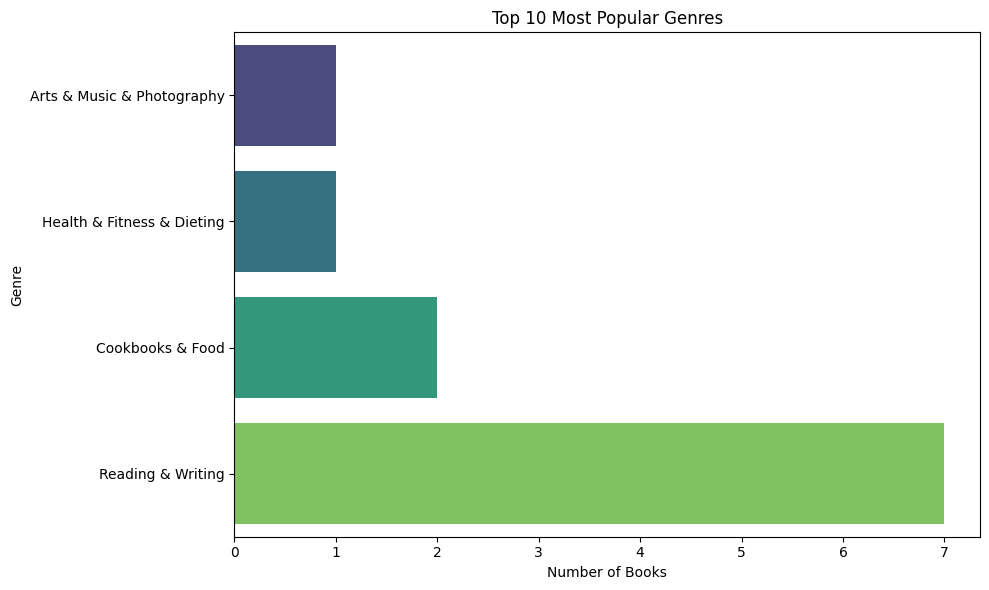

/tmp/ipykernel_6765/784352380.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=author_counts.index, y=author_counts.values, palette='magma')


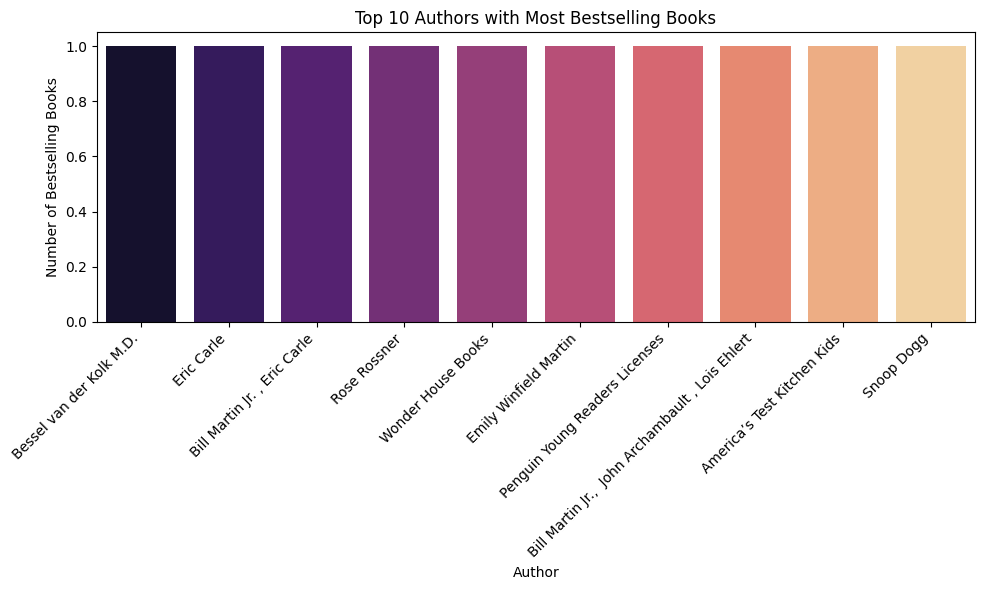

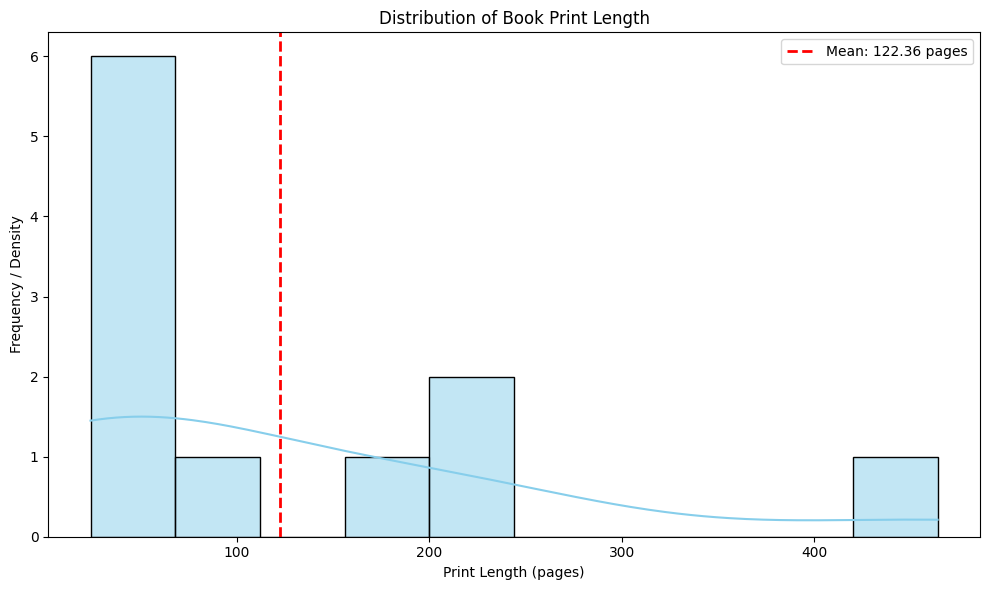

In [73]:


# --- Visualisasi Genre: Horizontal Bar Chart untuk Top 10 Genre Paling Populer ---
plt.figure(figsize=(10, 6))
genre_counts = df['Genre'].value_counts().head(10).sort_values(ascending=True)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Most Popular Genres')
plt.xlabel('Number of Books')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

# --- Visualisasi Penulis: Bar Chart untuk Top 10 Penulis dengan Buku Bestseller Terbanyak ---
plt.figure(figsize=(10, 6))
author_counts = df['Author'].value_counts().head(10)
sns.barplot(x=author_counts.index, y=author_counts.values, palette='magma')
plt.title('Top 10 Authors with Most Bestselling Books')
plt.xlabel('Author')
plt.ylabel('Number of Bestselling Books')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# --- Distribusi Halaman: Histogram/Density Plot untuk kolom Print Length ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Print Length'], kde=True, bins=10, color='skyblue')
mean_print_length = df['Print Length'].mean()
plt.axvline(mean_print_length, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_print_length:.2f} pages')
plt.title('Distribution of Book Print Length')
plt.xlabel('Print Length (pages)')
plt.ylabel('Frequency / Density')
plt.legend()
plt.tight_layout()
plt.show()

Berdasarkan analisis data eksploratif (exploratory data analysis) dan visualisasinya, berikut adalah beberapa wawasan (insights) utamanya:

    Genre Dominan: Genre 'Reading & Writing' (Membaca & Menulis) sangat mendominasi dalam daftar buku bestseller yang difilter ini, mencakup 7 dari 11 buku. Hal ini menjadi indikator kuat tingginya minat dan permintaan pasar untuk buku-buku dalam kategori ini, yang berpotensi menjadi ceruk pasar yang sangat menjanjikan bagi para penerbit.

    Keberagaman Penulis (Author Diversity): Tidak seperti skenario di mana segelintir penulis mendominasi daftar, dataset 11 buku bestseller kita saat ini menunjukkan tingkat keberagaman penulis yang tinggi. Setiap 'penulis bintang' yang terdaftar—seperti Bessel van der Kolk M.D., Eric Carle, dan Wonder House Books—hanya muncul satu kali. Hal ini mengindikasikan bahwa buku-buku bestseller ini tidak hanya berpusat pada beberapa penulis produktif, melainkan tersebar ke berbagai kreator yang lebih luas. Bagi penerbit, ini bisa berarti risiko bisnis yang lebih rendah karena tidak perlu bergantung pada satu atau dua penulis saja untuk meraih kesuksesan yang berkelanjutan pada kategori spesifik ini.

    Karakteristik Fisik Buku (Jumlah Halaman): Distribusi jumlah halaman buku (print length) cukup bervariasi, dengan rata-rata (mean) sekitar 122 halaman tetapi dengan nilai tengah (median) yang jauh lebih rendah, yaitu 36 halaman. Hal ini menunjukkan bahwa meskipun ada beberapa buku bestseller yang cukup tebal (hingga 464 halaman), mayoritas buku dalam daftar ini cenderung lebih tipis. Buku-buku dengan jumlah halaman yang sangat sedikit (misalnya, sekitar 24-36 halaman, yang biasanya berupa board books atau buku anak-anak) terbukti cukup sukses, bersanding dengan beberapa judul yang jauh lebih tebal. Ini mengisyaratkan bahwa untuk menjadi bestseller, ketebalan buku bukanlah hambatan utama; buku yang sangat pendek maupun cukup panjang sama-sama bisa sukses, meskipun ada kecenderungan kuat terhadap format yang lebih pendek pada sampel data spesifik ini.